# Custom Vision Partitioners

> Any custom vision paritioner that is not a built-in paritioner in flower-dataset library.


In [ ]:
#| default_exp data.vision.partitioners

In [ ]:
#| hide
from nbdev.showdoc import *

In [93]:
#| export
import numpy as np
from fastcore.utils import *
import warnings
from typing import Any, Dict, Literal, List, Optional, Union

import datasets
from flwr_datasets.common.typing import NDArray, NDArrayFloat, NDArrayInt
from flwr_datasets.partitioner.partitioner import Partitioner


## Rotated and Masked MNIST


In [2]:
#| export
class RotatedPatchedPartitioner(Partitioner):
    def __init__(self, num_partitions=40, num_rotations=4, patch_size=2, seed=42):
        super().__init__()
        self._num_partitions = num_partitions
        self.num_rotations = num_rotations
        self.patch_size = patch_size
        self.noise_levels = [0.0, 0.15, 0.30, 0.50]
        self.root_seed = int((np.e ** np.euler_gamma) ** np.pi * 1000)
        self.seed = self.root_seed

    @property
    def num_partitions(self) -> int:
        return self._num_partitions

    def load_partition(self, partition_id: int):
        dataset = self.dataset
        total_len = len(dataset)
        
        # 1. Standard Slicing
        samples_per_client = total_len // self._num_partitions
        start_idx = partition_id * samples_per_client
        end_idx = (partition_id + 1) * samples_per_client
        partition = dataset.select(range(start_idx, end_idx))
        
        # 2. Define the clusters seen in the paper (Figure A1)
        # We map partition_id to one of 4 clusters
        num_clusters = 4
        clients_per_cluster = self._num_partitions // num_clusters
        cluster_idx = partition_id // clients_per_cluster
        
        # 3. Assign rotation and noise based on the cluster index
        # Cluster 1: 0°, 0% Masked
        # Cluster 2: 90°, 0% Masked 
        # Cluster 3: 180°, 15% Masked
        # Cluster 4: 270°, 30-50% Masked (we can alternate or use partition_id for variety)
        
        rotations = [0, 1, 2, 3] # k values for 0, 90, 180, 270 degrees
        rotation_k = rotations[cluster_idx]
        
        # Map clusters to noise levels as per Figure A1
        if cluster_idx == 0: # Cluster 1
            current_noise = 0.0
        elif cluster_idx == 1: # Cluster 2
            current_noise = 0.0
        elif cluster_idx == 2: # Cluster 3
            current_noise = 0.15
        else: # Cluster 4 (Alternating 30% and 50% for high noise variety)
            current_noise = 0.30 if (partition_id % 2 == 0) else 0.50

        # 4. Generate the silo-specific mask
        if self.patch_size > 0 and current_noise > 0:
            # Pass current_noise to the mask generator
            mask = self._generate_mask(partition_id, current_noise)
        else:
            # Return a zero mask if no noise is applied
            mask = np.zeros((28, 28), dtype=np.float32)

        print(f"Partition {partition_id}: Cluster {cluster_idx + 1}, "
            f"Rot: {rotation_k * 90}°, Noise: {current_noise * 100}%")
        
        # 5. Attach metadata for the VisionBlock transform
        partition.rotation_k = rotation_k
        partition.silo_mask = mask
        partition.noise_level = current_noise # Useful for logging
        
        return partition
    
    def _generate_mask(self, p_id, noise_level):
        # Authors use a seed based on the root_seed + silo_id for intra-cluster diff
        rand = np.random.default_rng(seed=self.root_seed + p_id)
        w, h = 28, 28
        
        # Determine grid size for patches
        grid_w = int(np.ceil(w / self.patch_size))
        grid_h = int(np.ceil(h / self.patch_size))
        
        # Create mask: 1 is a white patch, 0 is original data
        mask_grid = rand.choice([0, 1], size=(grid_w, grid_h), 
                                p=[1 - noise_level, noise_level])
        
        # Upscale to 28x28
        noise_patch = np.kron(mask_grid, np.ones((self.patch_size, self.patch_size)))
        return noise_patch[:w, :h] # Crop to exact MNIST size
    

In [3]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
test_partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 0)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner, "test": test_partitioner}
)

Partition 12: Cluster 2, Rot: 90°, Noise: 0.0%


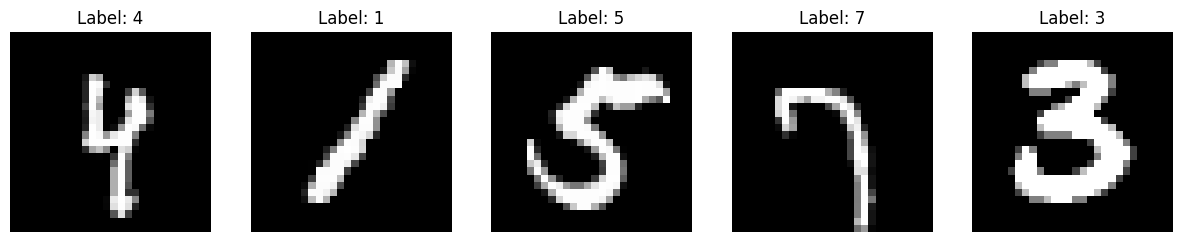

In [4]:
#| hide
import matplotlib.pyplot as plt
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = np.array(partition[i]['image']).squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
client_data = fds.load_partition(idx, "train")
plot_client_samples(client_data, num_samples=5)

## Variable Classes Partitioner

> Flexible pathological partitioner with variable classes per partition

Partition dataset with a variable number of classes per partition. Each partition can have a different number of classes assigned to it. This extends the pathological partitioning concept to support heterogeneous class distributions across clients

In [95]:
#| export
class VariableClassPartitioner(Partitioner):
    """
    Parameters
    ----------
    num_partitions : int
        The total number of partitions (clients).
    partition_by : str
        Column name of the labels (targets) based on which partitioning works.
    num_classes_per_partition : Union[int, List[int], Dict[int, int]]
        Controls how many unique classes each partition receives. Accepts:

        - ``int``: Every partition gets the same number of classes (identical
          to the original PathologicalPartitioner behaviour).
        - ``List[int]``: Element ``i`` specifies the class count for partition
          ``i``. Length must equal ``num_partitions``.
        - ``Dict[int, int]``: Maps ``partition_id -> num_classes``. Any
          partition not present in the dict falls back to
          ``default_num_classes``.
    default_num_classes : int, optional
        Fallback class count used when a partition is absent from a dict
        supplied to ``num_classes_per_partition``. Defaults to 1.
    class_assignment_mode : Literal["random", "deterministic", "first-deterministic"]
        How classes are assigned to partitions (same semantics as the
        original partitioner). Defaults to ``"random"``.
    shuffle : bool
        Whether to shuffle samples within each partition after assignment.
    seed : int, optional
        Random seed for reproducibility.

    Examples
    --------
    Give every client a different number of classes via a list:

    >>> partitioner = VariableClassPartitioner(
    ...     num_partitions=5,
    ...     partition_by="label",
    ...     num_classes_per_partition=[1, 2, 3, 2, 1],
    ... )

    Use a dict to override only specific clients (others default to 2):

    >>> partitioner = VariableClassPartitioner(
    ...     num_partitions=10,
    ...     partition_by="label",
    ...     num_classes_per_partition={0: 1, 4: 5, 9: 3},
    ...     default_num_classes=2,
    ... )
    """

    def __init__(
        self,
        num_partitions: int,
        partition_by: str,
        num_classes_per_partition: Union[int, List[int], Dict[int, int]],
        default_num_classes: int = 1,
        class_assignment_mode: Literal[
            "random", "deterministic", "first-deterministic"
        ] = "random",
        shuffle: bool = True,
        seed: Optional[int] = 42,
    ) -> None:
        super().__init__()
        self._num_partitions = num_partitions
        self._partition_by = partition_by
        self._class_assignment_mode = class_assignment_mode
        self._shuffle = shuffle
        self._seed = seed
        self._rng = np.random.default_rng(seed=self._seed)
        self._default_num_classes = default_num_classes

        # Normalise the num_classes_per_partition argument into a plain list
        # indexed by partition_id so the rest of the code has one code path.
        self._classes_per_partition: List[int] = self._normalise_class_counts(
            num_classes_per_partition, num_partitions, default_num_classes
        )

        # Utility attributes (same pattern as PathologicalPartitioner)
        self._partition_id_to_indices: Dict[int, List[int]] = {}
        self._partition_id_to_unique_labels: Dict[int, List[Any]] = {
            pid: [] for pid in range(self._num_partitions)
        }
        self._unique_labels: List[Any] = []
        self._unique_label_to_times_used_counter: Dict[Any, int] = {}
        self._partition_id_to_indices_determined = False

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def load_partition(self, partition_id: int) -> datasets.Dataset:
        """Load a single partition by its index."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self.dataset.select(self._partition_id_to_indices[partition_id])

    @property
    def num_partitions(self) -> int:
        """Total number of partitions."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self._num_partitions

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _normalise_class_counts(
        spec: Union[int, List[int], Dict[int, int]],
        num_partitions: int,
        default: int,
    ) -> List[int]:
        """Convert any supported input format into a per-partition list."""
        if isinstance(spec, int):
            return [spec] * num_partitions

        if isinstance(spec, list):
            if len(spec) != num_partitions:
                raise ValueError(
                    f"When `num_classes_per_partition` is a list its length "
                    f"({len(spec)}) must equal `num_partitions` ({num_partitions})."
                )
            return list(spec)

        if isinstance(spec, dict):
            return [spec.get(pid, default) for pid in range(num_partitions)]

        raise TypeError(
            "`num_classes_per_partition` must be an int, list, or dict. "
            f"Got {type(spec)}."
        )

    def _determine_partition_id_to_indices_if_needed(self) -> None:
        if self._partition_id_to_indices_determined:
            return

        self._determine_partition_id_to_unique_labels()
        self._count_partitions_having_each_unique_label()

        labels = np.asarray(self.dataset[self._partition_by])
        self._check_correctness_of_unique_label_to_times_used_counter(labels)

        for partition_id in range(self._num_partitions):
            self._partition_id_to_indices[partition_id] = []

        unused_labels = []
        for unique_label in self._unique_labels:
            times_used = self._unique_label_to_times_used_counter[unique_label]
            if times_used == 0:
                unused_labels.append(unique_label)
                continue

            label_indices = np.where(labels == unique_label)[0]
            splits = np.array_split(label_indices, times_used)

            split_index = 0
            for partition_id in range(self._num_partitions):
                if unique_label in self._partition_id_to_unique_labels[partition_id]:
                    self._partition_id_to_indices[partition_id].extend(splits[split_index])
                    split_index += 1

        if unused_labels:
            warnings.warn(
                f"Classes {unused_labels} are not assigned to any partition "
                f"under the current configuration and will be excluded from "
                f"the dataset entirely.",
                stacklevel=1,
            )

        if self._shuffle:
            for indices in self._partition_id_to_indices.values():
                self._rng.shuffle(indices)

        self._partition_id_to_indices_determined = True

    def _check_num_partitions_correctness_if_needed(self) -> None:
        if not self._partition_id_to_indices_determined:
            if self._num_partitions > self.dataset.num_rows:
                raise ValueError(
                    "num_partitions must be smaller than the number of samples."
                )

    def _determine_partition_id_to_unique_labels(self) -> None:
        """Assign unique labels to each partition respecting per-partition counts."""
        self._unique_labels = sorted(self.dataset.unique(self._partition_by))
        num_unique_classes = len(self._unique_labels)

        # Validate every partition's class count against the available classes
        for pid, n in enumerate(self._classes_per_partition):
            if n > num_unique_classes:
                raise ValueError(
                    f"Partition {pid} requests {n} classes but the dataset "
                    f"only has {num_unique_classes} unique classes."
                )

        if self._class_assignment_mode == "first-deterministic":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                # Pin the first class deterministically, fill the rest randomly
                first = self._unique_labels[pid % num_unique_classes]
                assigned = [first]
                while len(assigned) < n:
                    candidate = self._rng.choice(self._unique_labels)
                    if candidate not in assigned:
                        assigned.append(candidate)
                self._partition_id_to_unique_labels[pid] = assigned

        elif self._class_assignment_mode == "deterministic":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                assigned = [
                    self._unique_labels[(pid + i) % num_unique_classes]
                    for i in range(n)
                ]
                self._partition_id_to_unique_labels[pid] = assigned

        elif self._class_assignment_mode == "random":
            for pid in range(self._num_partitions):
                n = self._classes_per_partition[pid]
                assigned = self._rng.choice(
                    self._unique_labels, size=n, replace=False
                ).tolist()
                self._partition_id_to_unique_labels[pid] = assigned

        else:
            raise ValueError(
                f"Unsupported class_assignment_mode: '{self._class_assignment_mode}'. "
                f"Choose from 'random', 'deterministic', 'first-deterministic'."
            )

    def _count_partitions_having_each_unique_label(self) -> None:
        for unique_label in self._unique_labels:
            self._unique_label_to_times_used_counter[unique_label] = 0
        for labels in self._partition_id_to_unique_labels.values():
            for label in labels:
                self._unique_label_to_times_used_counter[label] += 1

    def _check_correctness_of_unique_label_to_times_used_counter(
        self, labels: NDArray
    ) -> None:
        for unique_label in self._unique_labels:
            num_samples = int(np.sum(labels == unique_label))
            times_needed = self._unique_label_to_times_used_counter[unique_label]
            if times_needed > num_samples:
                raise ValueError(
                    f"Label '{unique_label}' must be split across {times_needed} "
                    f"partitions but only {num_samples} samples exist for it. "
                    f"Reduce num_partitions, lower the class counts, or use a "
                    f"dataset with more samples per class."
                )

In [8]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = VariableClassPartitioner(num_partitions=20, partition_by="label", num_classes_per_partition={0: 1, 1: 2, 2: 3, 3: 4, 4: 5}, default_num_classes=2)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner}
)

11


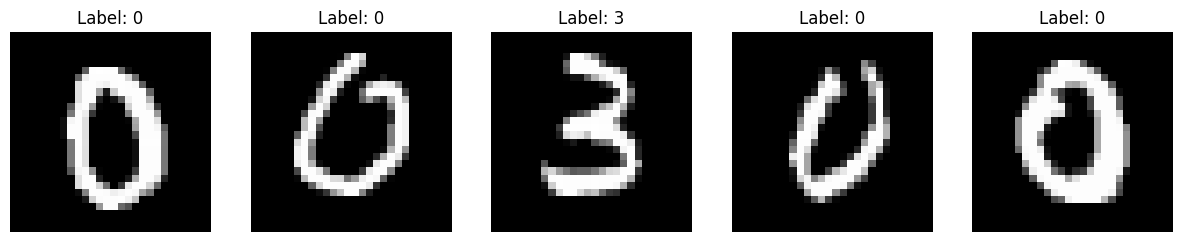

In [22]:
#| hide
import matplotlib.pyplot as plt
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = np.array(partition[i]['image']).squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
print(idx)
client_data = fds.load_partition(idx, "train")
plot_client_samples(client_data, num_samples=5)

In [23]:
#| hide
for client_idx in range(20):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}")

Client 0: [0]
Client 1: [6 9]
Client 2: [0 3 7]
Client 3: [0 4 7 8]
Client 4: [0 3 4 5 6]
Client 5: [4 5]
Client 6: [4 9]
Client 7: [0 2]
Client 8: [0 7]
Client 9: [2 7]
Client 10: [1 7]
Client 11: [0 3]
Client 12: [4 8]
Client 13: [7 9]
Client 14: [3 4]
Client 15: [0 5]
Client 16: [6 9]
Client 17: [3 6]
Client 18: [3 9]
Client 19: [0 3]


In [24]:
#| hide
from flwr_datasets import FederatedDataset

mapping = {i: i + 1 for i in range(10)} # Client 0 gets 1 class, client 1 gets 2 classes, ..., client 9 gets all 10 classes
mapping.update({i: 2 for i in range(10, 70)}) # Clients 10-99 get 2 classes each
partitioner = VariableClassPartitioner(num_partitions=100, partition_by="label", num_classes_per_partition=mapping, default_num_classes=4)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner}
)

In [26]:
#| hide
for client_idx in range(100):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}")

Client 0: [0]
Client 1: [6 9]
Client 2: [0 3 7]
Client 3: [0 4 7 8]
Client 4: [0 3 4 5 6]
Client 5: [2 3 4 5 8 9]
Client 6: [1 3 4 6 7 8 9]


Client 7: [0 2 3 5 6 7 8 9]
Client 8: [0 1 2 3 4 5 6 7 8]
Client 9: [0 1 2 3 4 5 6 7 8 9]
Client 10: [1 8]
Client 11: [0 7]
Client 12: [7 9]
Client 13: [4 7]
Client 14: [5 7]
Client 15: [4 5]
Client 16: [1 2]
Client 17: [3 6]
Client 18: [4 8]
Client 19: [0 7]
Client 20: [5 9]
Client 21: [0 5]
Client 22: [2 6]
Client 23: [3 4]
Client 24: [1 2]
Client 25: [8 9]
Client 26: [2 8]
Client 27: [2 7]
Client 28: [2 4]
Client 29: [1 5]
Client 30: [7 9]
Client 31: [3 4]
Client 32: [3 7]
Client 33: [0 3]
Client 34: [0 7]
Client 35: [4 6]
Client 36: [1 9]
Client 37: [1 8]
Client 38: [4 6]
Client 39: [1 3]
Client 40: [2 6]
Client 41: [3 5]
Client 42: [0 3]
Client 43: [3 9]
Client 44: [4 8]
Client 45: [2 4]
Client 46: [2 8]
Client 47: [2 7]
Client 48: [4 7]
Client 49: [0 9]
Client 50: [1 8]
Client 51: [2 6]
Client 52: [2 8]
Client 53: [1 4]
Client 54: [0 7]
Client 55: [4 7]
Client 56: [3 9]
Client 57: [1 5]
Client 58: [5 6]
Client 59: [4 6]
Client 60: [0 1]
Client 61: [1 3]
Client 62: [1 6]
Client 63

## Grouped Partitioner
> Grouped pathological partitioner — clients within a group share a class pool.

Partition dataset so that clients within a group share the same class pool:
- Clients are divided into groups.
- Each group is randomly assigned a pool of classes, and very client in that group receives samples drawn exclusively from that pool.
- Within a group, each client gets a random subset of the pool (of size ``num_classes_per_client``) so individual clients are still heterogeneous — but they only ever see classes from their group's pool.


In [ ]:
#| export

class GroupedClassPartitioner(Partitioner):
    """
    Parameters
    ----------
    num_partitions : int
        Total number of clients / partitions.
    partition_by : str
        Column name of the label column.
    num_groups : int
        Number of client groups. ``num_partitions`` must be divisible by
        ``num_groups`` unless ``group_sizes`` is provided.
    num_classes_per_group : int
        How many classes are in each group's pool.
    num_classes_per_client : int
        How many classes from the group pool each individual client sees.
        Must satisfy ``num_classes_per_client <= num_classes_per_group``.
    group_sizes : List[int], optional
        Explicit size for each group. Must sum to ``num_partitions``.
        When omitted, clients are split evenly across groups.
    shuffle : bool
        Whether to shuffle samples within each partition after assignment.
    seed : int, optional
        Random seed for reproducibility.

    Examples
    --------
    Ten clients, two groups of five, each group gets 3 classes from a 5-class
    dataset, each client sees 2 of those 3:

    >>> partitioner = GroupedClassPartitioner(
    ...     num_partitions=10,
    ...     partition_by="label",
    ...     num_groups=2,
    ...     num_classes_per_group=3,
    ...     num_classes_per_client=2,
    ... )

    Unequal group sizes — first group has 3 clients, second has 7:

    >>> partitioner = GroupedClassPartitioner(
    ...     num_partitions=10,
    ...     partition_by="label",
    ...     num_groups=2,
    ...     num_classes_per_group=4,
    ...     num_classes_per_client=2,
    ...     group_sizes=[3, 7],
    ... )
    """

    def __init__(
        self,
        num_partitions: int,
        partition_by: str,
        num_groups: int,
        num_classes_per_group: int,
        num_classes_per_client: int,
        group_sizes: Optional[List[int]] = None,
        shuffle: bool = True,
        seed: Optional[int] = 42,
    ) -> None:
        super().__init__()
        self._num_partitions = num_partitions
        self._partition_by = partition_by
        self._num_groups = num_groups
        self._num_classes_per_group = num_classes_per_group
        self._num_classes_per_client = num_classes_per_client
        self._shuffle = shuffle
        self._seed = seed
        self._rng = np.random.default_rng(seed=self._seed)

        self._group_sizes: List[int] = self._resolve_group_sizes(
            group_sizes, num_partitions, num_groups
        )

        # Maps partition_id -> group_id for quick lookup
        self._partition_to_group: Dict[int, int] = {}
        pid = 0
        for gid, size in enumerate(self._group_sizes):
            for _ in range(size):
                self._partition_to_group[pid] = gid
                pid += 1

        # Populated lazily
        self._partition_id_to_indices: Dict[int, List[int]] = {}
        self._group_id_to_class_pool: Dict[int, List[Any]] = {}
        self._partition_id_to_unique_labels: Dict[int, List[Any]] = {}
        self._unique_label_to_times_used_counter: Dict[Any, int] = {}
        self._unique_labels: List[Any] = []
        self._partition_id_to_indices_determined = False

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def load_partition(self, partition_id: int) -> datasets.Dataset:
        """Load a single partition by its index."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self.dataset.select(self._partition_id_to_indices[partition_id])

    @property
    def num_partitions(self) -> int:
        """Total number of partitions."""
        self._check_num_partitions_correctness_if_needed()
        self._determine_partition_id_to_indices_if_needed()
        return self._num_partitions

    @property
    def group_class_pools(self) -> Dict[int, List[Any]]:
        """Expose the randomly assigned class pool for each group (read-only view).
        
        Useful for logging / debugging after the first partition is loaded.
        """
        self._determine_partition_id_to_indices_if_needed()
        return dict(self._group_id_to_class_pool)

    @property
    def partition_label_assignment(self) -> Dict[int, List[Any]]:
        """Return the classes assigned to every individual client partition."""
        self._determine_partition_id_to_indices_if_needed()
        return dict(self._partition_id_to_unique_labels)

    # ------------------------------------------------------------------
    # Core logic
    # ------------------------------------------------------------------

    def _determine_partition_id_to_indices_if_needed(self) -> None:
        if self._partition_id_to_indices_determined:
            return

        self._unique_labels = sorted(self.dataset.unique(self._partition_by))
        self._validate_class_counts()

        # Step 1 — randomly assign a disjoint(ish) class pool to each group
        self._assign_class_pools_to_groups()

        # Step 2 — for each client, pick a random subset of its group's pool
        self._assign_labels_to_partitions()

        # Step 3 — count how many partitions need each label (for splitting)
        self._count_partitions_having_each_unique_label()

        # Step 4 — split samples and assign indices to partitions
        labels = np.asarray(self.dataset[self._partition_by])
        self._check_correctness_of_unique_label_to_times_used_counter(labels)
        self._build_partition_indices(labels)

        if self._shuffle:
            for indices in self._partition_id_to_indices.values():
                self._rng.shuffle(indices)

        self._partition_id_to_indices_determined = True

    def _assign_class_pools_to_groups(self) -> None:
        """Assign class pools to groups with minimal overlap.

        When total slots (num_groups * num_classes_per_group) <= num_unique,
        pools are fully disjoint. When overlap is unavoidable, it is spread
        as evenly as possible across groups rather than concentrated.
        """
        num_unique = len(self._unique_labels)
        total_slots = self._num_groups * self._num_classes_per_group

        # Normalise all labels to plain Python objects up front
        unique_labels = [label.item() if hasattr(label, "item") else label
                        for label in self._unique_labels]

        pools: Dict[int, List[Any]] = {gid: [] for gid in range(self._num_groups)}

        if total_slots <= num_unique:
            # ── Fully disjoint assignment ──────────────────────────────────
            # Shuffle then slice contiguous blocks — zero overlap guaranteed.
            shuffled = self._rng.permutation(unique_labels).tolist()
            for gid in range(self._num_groups):
                start = gid * self._num_classes_per_group
                pools[gid] = shuffled[start : start + self._num_classes_per_group]
        else:
            # ── Overlap is unavoidable — minimise and spread it evenly ─────
            # How many extra slots need filling beyond a full unique-label pass?
            overflow = total_slots - num_unique

            # Shuffle labels once; assign one pass round-robin (covers num_unique
            # slots), then fill overflow by picking least-used labels first.
            shuffled = self._rng.permutation(unique_labels).tolist()

            # First pass: deal every label exactly once
            for i, label in enumerate(shuffled):
                gid = i % self._num_groups
                pools[gid].append(label)

            # Track how many times each label has been assigned globally
            label_usage: Dict[Any, int] = {l: 0 for l in unique_labels}
            for pool in pools.values():
                for l in pool:
                    label_usage[l] += 1

            # Second pass: fill groups that still need more classes,
            # always picking the globally least-used label not already in the pool
            for gid in range(self._num_groups):
                while len(pools[gid]) < self._num_classes_per_group:
                    available = sorted(
                        [l for l in unique_labels if l not in pools[gid]],
                        key=lambda l: label_usage[l],   # least used first
                    )
                    if not available:
                        # Absolute fallback: every label is already in this pool
                        # (only possible if num_classes_per_group == num_unique)
                        available = sorted(unique_labels, key=lambda l: label_usage[l])

                    chosen = available[0]
                    pools[gid].append(chosen)
                    label_usage[chosen] += 1

            warnings.warn(
                f"num_classes_per_group ({self._num_classes_per_group}) × "
                f"num_groups ({self._num_groups}) = {total_slots} exceeds the "
                f"number of unique classes ({num_unique}). "
                f"Some classes will appear in more than one group's pool. "
                f"Overlap has been spread as evenly as possible.",
                stacklevel=1,
            )

        self._group_id_to_class_pool = pools


    def _validate_class_counts(self) -> None:
        num_unique = len(self._unique_labels)
        if self._num_classes_per_group > num_unique:
            raise ValueError(
                f"`num_classes_per_group` ({self._num_classes_per_group}) exceeds "
                f"the number of unique classes in the dataset ({num_unique})."
            )
        if self._num_classes_per_client > self._num_classes_per_group:
            raise ValueError(
                f"`num_classes_per_client` ({self._num_classes_per_client}) cannot "
                f"exceed `num_classes_per_group` ({self._num_classes_per_group})."
            )
        # Inform the user upfront if overlap is unavoidable
        total_slots = self._num_groups * self._num_classes_per_group
        if total_slots > num_unique:
            min_overlap = total_slots - num_unique
            warnings.warn(
                f"Configuration requires {total_slots} class slots across "
                f"{self._num_groups} groups but only {num_unique} unique classes "
                f"exist. At least {min_overlap} overlap(s) across groups are "
                f"unavoidable.",
                stacklevel=1,
            )

    def _assign_labels_to_partitions(self) -> None:
        """Each client randomly draws ``num_classes_per_client`` from its group pool."""
        for pid in range(self._num_partitions):
            gid = self._partition_to_group[pid]
            pool = self._group_id_to_class_pool[gid]
            chosen = self._rng.choice(
                pool, size=self._num_classes_per_client, replace=False
            ).tolist()
            self._partition_id_to_unique_labels[pid] = chosen

    def _build_partition_indices(self, labels: NDArray) -> None:
        """Split per-label sample indices and distribute to partitions."""
        for pid in range(self._num_partitions):
            self._partition_id_to_indices[pid] = []

        unused_labels = []
        for unique_label in self._unique_labels:
            times_used = self._unique_label_to_times_used_counter[unique_label]
            if times_used == 0:
                unused_labels.append(unique_label)
                continue

            label_indices = np.where(labels == unique_label)[0]
            splits = np.array_split(label_indices, times_used)

            split_index = 0
            for pid in range(self._num_partitions):
                if unique_label in self._partition_id_to_unique_labels[pid]:
                    self._partition_id_to_indices[pid].extend(splits[split_index])
                    split_index += 1

        if unused_labels:
            warnings.warn(
                f"Classes {unused_labels} were not assigned to any partition "
                f"and will be excluded from the federated dataset.",
                stacklevel=1,
            )

    # ------------------------------------------------------------------
    # Validation & counting helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _resolve_group_sizes(
        group_sizes: Optional[List[int]],
        num_partitions: int,
        num_groups: int,
    ) -> List[int]:
        if group_sizes is not None:
            if len(group_sizes) != num_groups:
                raise ValueError(
                    f"`group_sizes` length ({len(group_sizes)}) must equal "
                    f"`num_groups` ({num_groups})."
                )
            if sum(group_sizes) != num_partitions:
                raise ValueError(
                    f"`group_sizes` must sum to `num_partitions` ({num_partitions}), "
                    f"got {sum(group_sizes)}."
                )
            return group_sizes

        if num_partitions % num_groups != 0:
            raise ValueError(
                f"`num_partitions` ({num_partitions}) is not evenly divisible by "
                f"`num_groups` ({num_groups}). Provide explicit `group_sizes` or "
                f"choose compatible values."
            )
        size = num_partitions // num_groups
        return [size] * num_groups


    def _check_num_partitions_correctness_if_needed(self) -> None:
        if not self._partition_id_to_indices_determined:
            if self._num_partitions > self.dataset.num_rows:
                raise ValueError(
                    "num_partitions must be smaller than the number of samples."
                )

    def _count_partitions_having_each_unique_label(self) -> None:
        for label in self._unique_labels:
            self._unique_label_to_times_used_counter[label] = 0
        for labels in self._partition_id_to_unique_labels.values():
            for label in labels:
                self._unique_label_to_times_used_counter[label] += 1

    def _check_correctness_of_unique_label_to_times_used_counter(
        self, labels: NDArray
    ) -> None:
        for unique_label in self._unique_labels:
            num_samples = int(np.sum(labels == unique_label))
            times_needed = self._unique_label_to_times_used_counter[unique_label]
            if times_needed > num_samples:
                raise ValueError(
                    f"Label '{unique_label}' must be split across {times_needed} "
                    f"partitions but only {num_samples} samples exist. "
                    f"Reduce num_partitions, num_classes_per_client, or use a "
                    f"larger dataset."
                )

In [89]:
#| hide
from flwr_datasets import FederatedDataset

partitioner = GroupedClassPartitioner(num_partitions=20, partition_by="label", num_groups=5, num_classes_per_group=3, num_classes_per_client=2)
fds = FederatedDataset(
    dataset="uoft-cs/cifar10", 
    partitioners={"train": partitioner}
)

In [90]:
#| hide
for client_idx in range(20):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}")

/tmp/ipykernel_96998/3625774981.py:251: UserWarning: Configuration requires 15 class slots across 5 groups but only 10 unique classes exist. At least 5 overlap(s) across groups are unavoidable.
  warnings.warn(
/tmp/ipykernel_96998/3625774981.py:223: UserWarning: num_classes_per_group (3) × num_groups (5) = 15 exceeds the number of unique classes (10). Some classes will appear in more than one group's pool. Overlap has been spread as evenly as possible.
  warnings.warn(


Client 0: [0 2]
Client 1: [0 2]
Client 2: [0 2]
Client 3: [0 5]
Client 4: [1 4]
Client 5: [1 4]
Client 6: [1 6]
Client 7: [1 4]
Client 8: [2 9]
Client 9: [0 9]
Client 10: [2 9]
Client 11: [2 9]
Client 12: [1 3]
Client 13: [1 7]
Client 14: [3 7]
Client 15: [3 7]
Client 16: [4 8]
Client 17: [4 8]
Client 18: [4 8]
Client 19: [3 4]


In [91]:
#| hide
partitioner.group_class_pools

{0: [5, 2, 0], 1: [6, 4, 1], 2: [0, 9, 2], 3: [7, 1, 3], 4: [3, 8, 4]}

In [92]:
#| hide
partitioner.partition_label_assignment

{0: [2, 0],
 1: [0, 2],
 2: [2, 0],
 3: [5, 0],
 4: [1, 4],
 5: [1, 4],
 6: [1, 6],
 7: [1, 4],
 8: [2, 9],
 9: [9, 0],
 10: [2, 9],
 11: [9, 2],
 12: [1, 3],
 13: [1, 7],
 14: [7, 3],
 15: [7, 3],
 16: [4, 8],
 17: [4, 8],
 18: [4, 8],
 19: [4, 3]}

## Grouped Distribution Partitioner

> Grouped Distribution Partitioner — group-based class pools with per-client
sample-count skew drawn from a user-supplied distribution

Partition a dataset along two heterogeneity axes simultaneously:

1. Which classes each client sees  — controlled by group membership
       (same logic as ``GroupedClassPartitioner``).
2. **How many samples** of each class a client gets — controlled by a
       per-client distribution array (same logic as ``DistributionPartitioner``).

    Concretely:

    * Clients are divided into ``num_groups`` groups.
    * Each group is randomly assigned a pool of ``num_classes_per_group`` classes (maximally disjoint; overlap only when unavoidable).
    * Each client randomly draws ``num_classes_per_client`` classes from its group's pool.
    * Within those classes, the number of samples assigned to each client is governed by ``distribution_array`` — a 2-D array of shape ``(num_classes_per_client, num_partitions)`` that encodes the desired sample-count skew across clients *for each of their assigned classes*.

In [189]:
#| export

class GroupedDistributionPartitioner(Partitioner):
    """
    Parameters
    ----------
    num_partitions : int
        Total number of clients / partitions.
    partition_by : str
        Column name of the label column.
    num_groups : int
        Number of client groups.
    num_classes_per_group : int
        Size of the class pool assigned to each group.
    num_classes_per_client : int
        How many classes from the group pool each client sees.
        Must satisfy ``num_classes_per_client <= num_classes_per_group``.
    distribution_array : np.ndarray, shape (num_classes_per_client, num_partitions)
        Raw (un-normalised) weights controlling the sample-count split for
        each of the ``num_classes_per_client`` class slots across all
        ``num_partitions`` clients.  Rows correspond to *class slots* (slot 0
        is the first assigned class for every client, slot 1 the second, …),
        not to global class IDs.  Values are normalised per-row so only
        relative magnitudes matter.
    group_sizes : List[int], optional
        Explicit size for each group. Must sum to ``num_partitions``.
        When omitted clients are split evenly.
    preassigned_num_samples_per_label : int, default 0
        Minimum number of samples guaranteed to every client for each of its
        assigned classes, before the distribution weights are applied.
    shuffle : bool, default True
        Whether to shuffle samples within each partition after assignment.
    seed : int, optional, default 42
        Random seed for reproducibility.

    Examples
    --------
    Twenty clients, four groups, MNIST (10 classes).  Each group gets a pool
    of 3 classes; each client sees 2 of those 3.  A log-normal distribution
    controls the sample-count skew:

    >>> import numpy as np
    >>> from flwr_datasets import FederatedDataset
    >>>
    >>> rng = np.random.default_rng(42)
    >>> dist = rng.lognormal(0, 1, size=(2, 20))   # 2 class-slots × 20 clients
    >>>
    >>> partitioner = GroupedDistributionPartitioner(
    ...     num_partitions=20,
    ...     partition_by="label",
    ...     num_groups=4,
    ...     num_classes_per_group=3,
    ...     num_classes_per_client=2,
    ...     distribution_array=dist,
    ...     preassigned_num_samples_per_label=10,
    ... )
    >>> fds = FederatedDataset(dataset="ylecun/mnist",
    ...                        partitioners={"train": partitioner})
    >>> partition = fds.load_partition(0)
    """

    def __init__(
        self,
        num_partitions: int,
        partition_by: str,
        num_groups: int,
        num_classes_per_group: int,
        num_classes_per_client: int,
        distribution_array: Union[NDArrayInt, NDArrayFloat],
        rescale: bool = True, 
        group_sizes: Optional[List[int]] = None,
        preassigned_num_samples_per_label: int = 0,
        shuffle: bool = True,
        seed: Optional[int] = 42,
    ) -> None:
        super().__init__()
        self._num_partitions = num_partitions
        self._partition_by = partition_by
        self._num_groups = num_groups
        self._num_classes_per_group = num_classes_per_group
        self._num_classes_per_client = num_classes_per_client
        self._distribution_array = np.array(distribution_array, dtype=float)
        self._rescale = rescale  
        self._preassigned_num_samples = preassigned_num_samples_per_label
        self._shuffle = shuffle
        self._seed = seed
        self._rng = np.random.default_rng(seed=self._seed)

        # Resolve group sizes
        self._group_sizes: List[int] = self._resolve_group_sizes(
            group_sizes, num_partitions, num_groups
        )

        # partition_id -> group_id
        self._partition_to_group: Dict[int, int] = {}
        pid = 0
        for gid, size in enumerate(self._group_sizes):
            for _ in range(size):
                self._partition_to_group[pid] = gid
                pid += 1

        # Lazily populated
        self._partition_id_to_indices: Dict[int, List[int]] = {}
        self._group_id_to_class_pool: Dict[int, List[Any]] = {}
        # partition_id -> ordered list of assigned class labels
        # (order is preserved so it aligns with distribution_array rows)
        self._partition_id_to_unique_labels: Dict[int, List[Any]] = {}
        self._unique_labels: List[Any] = []
        self._partition_id_to_indices_determined = False

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def load_partition(self, partition_id: int) -> datasets.Dataset:
        """Load a single partition by its index."""
        self._check_num_partitions_correctness_if_needed()
        self._validate_distribution_array_shape()
        self._determine_partition_id_to_indices_if_needed()
        return self.dataset.select(self._partition_id_to_indices[partition_id])

    @property
    def num_partitions(self) -> int:
        """Total number of partitions."""
        return self._num_partitions

    @property
    def group_class_pools(self) -> Dict[int, List[Any]]:
        """Class pool assigned to each group (available after first load)."""
        self._determine_partition_id_to_indices_if_needed()
        return dict(self._group_id_to_class_pool)

    @property
    def partition_label_assignment(self) -> Dict[int, List[Any]]:
        """Ordered class list for every client (available after first load)."""
        self._determine_partition_id_to_indices_if_needed()
        return dict(self._partition_id_to_unique_labels)

    # ------------------------------------------------------------------
    # Core orchestration
    # ------------------------------------------------------------------

    def _determine_partition_id_to_indices_if_needed(self) -> None:
        if self._partition_id_to_indices_determined:
            return

        self._unique_labels = sorted(self.dataset.unique(self._partition_by))
        self._validate_class_counts()

        # ── Step 1: assign class pool to each group ────────────────────
        self._assign_class_pools_to_groups()

        # ── Step 2: each client picks a random subset of its group pool ─
        self._assign_labels_to_partitions()

        # ── Step 3: build per-(client, class-slot) sample budgets ───────
        # shape: (num_classes_per_client, num_partitions)
        sampling_matrix = self._build_sampling_matrix()

        # ── Step 4: distribute dataset indices to partitions ────────────
        labels_array = np.asarray(self.dataset[self._partition_by])
        self._build_partition_indices(labels_array, sampling_matrix)

        if self._shuffle:
            for indices in self._partition_id_to_indices.values():
                self._rng.shuffle(indices)

        self._partition_id_to_indices_determined = True

    # ------------------------------------------------------------------
    # Step 1 — group pool assignment (mirrors GroupedClassPartitioner)
    # ------------------------------------------------------------------

    def _assign_class_pools_to_groups(self) -> None:
        num_unique = len(self._unique_labels)
        total_slots = self._num_groups * self._num_classes_per_group

        # Normalise to plain Python to avoid np.int64 leaking into pools
        unique_labels = [
            lbl.item() if hasattr(lbl, "item") else lbl
            for lbl in self._unique_labels
        ]

        pools: Dict[int, List[Any]] = {gid: [] for gid in range(self._num_groups)}

        if total_slots <= num_unique:
            # Fully disjoint
            shuffled = self._rng.permutation(unique_labels).tolist()
            for gid in range(self._num_groups):
                s = gid * self._num_classes_per_group
                pools[gid] = shuffled[s: s + self._num_classes_per_group]
        else:
            # Overlap unavoidable — spread it evenly
            warnings.warn(
                f"num_classes_per_group ({self._num_classes_per_group}) × "
                f"num_groups ({self._num_groups}) = {total_slots} exceeds "
                f"num unique classes ({num_unique}). Some classes will appear "
                f"in more than one group pool. Overlap is spread evenly.",
                stacklevel=1,
            )
            shuffled = self._rng.permutation(unique_labels).tolist()
            for i, label in enumerate(shuffled):
                gid = i % self._num_groups
                if len(pools[gid]) < self._num_classes_per_group:
                    pools[gid].append(label)

            label_usage: Dict[Any, int] = {l: 0 for l in unique_labels}
            for pool in pools.values():
                for l in pool:
                    label_usage[l] += 1

            for gid in range(self._num_groups):
                while len(pools[gid]) < self._num_classes_per_group:
                    available = sorted(
                        [l for l in unique_labels if l not in pools[gid]],
                        key=lambda l: label_usage[l],
                    )
                    if not available:
                        available = sorted(unique_labels, key=lambda l: label_usage[l])
                    chosen = available[0]
                    pools[gid].append(chosen)
                    label_usage[chosen] += 1

        self._group_id_to_class_pool = pools

    # ------------------------------------------------------------------
    # Step 2 — per-client class subset
    # ------------------------------------------------------------------

    def _assign_labels_to_partitions(self) -> None:
        """Each client draws num_classes_per_client from its group's pool.

        The order of chosen labels is preserved — row i of
        distribution_array corresponds to class-slot i for every client.
        """
        for pid in range(self._num_partitions):
            gid = self._partition_to_group[pid]
            pool = self._group_id_to_class_pool[gid]
            chosen = self._rng.choice(
                pool, size=self._num_classes_per_client, replace=False
            ).tolist()
            self._partition_id_to_unique_labels[pid] = chosen

    # ------------------------------------------------------------------
    # Step 3 — sample budget matrix
    # ------------------------------------------------------------------


    def _build_sampling_matrix(self) -> NDArrayInt:
        if not self._rescale:
            matrix = self._build_sampling_matrix_from_counts()
        else:
            matrix = self._build_sampling_matrix_from_weights()
        self._last_sampling_matrix = matrix      # ← save for debugging
        return matrix


    def _build_sampling_matrix_from_counts(self) -> NDArrayInt:
        labels_array = np.asarray(self.dataset[self._partition_by])
        global_class_demand: Dict[Any, int] = {cls: 0 for cls in self._unique_labels}

        for slot in range(self._num_classes_per_client):
            for pid in range(self._num_partitions):
                cls = self._partition_id_to_unique_labels[pid][slot]
                global_class_demand[cls] += int(self._distribution_array[slot, pid])

        for cls in self._unique_labels:
            total_demanded = global_class_demand[cls]
            total_available = int(np.sum(labels_array == cls))
            if total_demanded > total_available:
                contributors = [
                    (slot, pid)
                    for slot in range(self._num_classes_per_client)
                    for pid in range(self._num_partitions)
                    if self._partition_id_to_unique_labels[pid][slot] == cls
                ]
                raise ValueError(
                    f"Class '{cls}': total demanded ({total_demanded}) exceeds "
                    f"available ({total_available}).\n"
                    f"Contributing (slot, client_id) pairs: {contributors}.\n"
                    f"Hint: safe upper bound per entry is "
                    f"~{total_available // max(len(contributors), 1)}."
                )

        return self._distribution_array.astype(int)



    def _build_sampling_matrix_from_weights(self) -> NDArrayInt:
        labels_array = np.asarray(self.dataset[self._partition_by])

        row_sums = self._distribution_array.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1, row_sums)
        norm_dist = self._distribution_array / row_sums

        sampling_matrix = np.zeros(
            (self._num_classes_per_client, self._num_partitions), dtype=int
        )

        # Pre-compute total number of (slot, client) assignments per class
        # across ALL slots — this is the true total demand we must fit within
        # total_available samples
        total_assignments_per_class: Dict[Any, int] = {
            cls: 0 for cls in self._unique_labels
        }
        for slot in range(self._num_classes_per_client):
            for pid in range(self._num_partitions):
                cls = self._partition_id_to_unique_labels[pid][slot]
                total_assignments_per_class[cls] += 1

        # Pre-compute the total sample budget available per class after
        # reserving the preassigned floor for every assignment of that class
        available_for_distribution: Dict[Any, int] = {}
        for cls in self._unique_labels:
            total_available = int(np.sum(labels_array == cls))
            total_floor = self._preassigned_num_samples * total_assignments_per_class[cls]
            available_for_distribution[cls] = max(0, total_available - total_floor)

        # Warn early if any class is already over-subscribed just from floors
        for cls in self._unique_labels:
            if available_for_distribution[cls] == 0:
                total_available = int(np.sum(labels_array == cls))
                n = total_assignments_per_class[cls]
                warnings.warn(
                    f"Class '{cls}' has {total_available} samples but "
                    f"{n} client-slot assignments × {self._preassigned_num_samples} "
                    f"floor = {n * self._preassigned_num_samples} samples needed "
                    f"just for floors. Reduce `preassigned_num_samples_per_label` "
                    f"or the number of clients sharing this class.",
                    stacklevel=1,
                )

        # Now assign distribution weights slot by slot, tracking committed budgets
        committed: Dict[Any, int] = {cls: 0 for cls in self._unique_labels}

        for slot in range(self._num_classes_per_client):
            slot_labels = [
                self._partition_id_to_unique_labels[pid][slot]
                for pid in range(self._num_partitions)
            ]

            for cls in set(slot_labels):
                client_ids = [
                    pid for pid in range(self._num_partitions)
                    if slot_labels[pid] == cls
                ]

                # How many distribution-weight samples remain for this class
                # after what earlier slots already committed
                remaining_for_distribution = max(
                    0, available_for_distribution[cls] - committed[cls]
                )

                weights = norm_dist[slot, client_ids]
                weight_sum = weights.sum()
                if weight_sum == 0:
                    weights = np.ones(len(client_ids)) / len(client_ids)
                    weight_sum = 1.0

                raw_counts = (weights / weight_sum) * remaining_for_distribution
                int_counts = np.floor(raw_counts).astype(int)
                remainder_samples = remaining_for_distribution - int_counts.sum()
                fractions = raw_counts - int_counts
                top_indices = np.argsort(fractions)[::-1][:remainder_samples]
                int_counts[top_indices] += 1

                for local_i, pid in enumerate(client_ids):
                    final = int_counts[local_i] + self._preassigned_num_samples
                    sampling_matrix[slot, pid] = final
                    # Only track the distribution portion in committed,
                    # floors are already accounted for in available_for_distribution
                    committed[cls] += int_counts[local_i]

        return sampling_matrix

    # ------------------------------------------------------------------
    # Step 4 — index assignment
    # ------------------------------------------------------
    def _build_partition_indices(self, labels_array: NDArray, sampling_matrix: NDArrayInt) -> None:
        class_to_indices: Dict[Any, List[int]] = {}
        for cls in self._unique_labels:
            idxs = np.where(labels_array == cls)[0].tolist()
            self._rng.shuffle(idxs)
            class_to_indices[cls] = idxs

        for pid in range(self._num_partitions):
            self._partition_id_to_indices[pid] = []

        unused_labels = []

        for cls in self._unique_labels:
            assignments: List[tuple] = []
            for pid in range(self._num_partitions):
                for slot, label in enumerate(self._partition_id_to_unique_labels[pid]):
                    if label == cls:
                        assignments.append((pid, slot))

            if not assignments:
                unused_labels.append(cls)
                continue

            available = class_to_indices[cls]
            ptr = 0              # ← local reset per class, never carried over

            for pid, slot in assignments:
                budget = sampling_matrix[slot, pid]
                end = min(ptr + budget, len(available))
                self._partition_id_to_indices[pid].extend(available[ptr:end])
                ptr = end

                if ptr >= len(available) and (pid, slot) != assignments[-1]:
                    warnings.warn(
                        f"Class '{cls}' ran out of samples before all clients "
                        f"received their full budget. Remaining assignments will "
                        f"be empty. Reduce counts or preassigned_num_samples.",
                        stacklevel=1,
                    )
                    break

            # Distribute leftover (rounding residuals) to a random client
            leftover = available[ptr:]
            if leftover:
                lucky_pid = self._rng.choice([a[0] for a in assignments])
                self._partition_id_to_indices[lucky_pid].extend(leftover)

        if unused_labels:
            warnings.warn(
                f"Classes {unused_labels} were not assigned to any partition "
                f"and will be excluded.",
                stacklevel=1,
            )
    # Validation helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _resolve_group_sizes(
        group_sizes: Optional[List[int]],
        num_partitions: int,
        num_groups: int,
    ) -> List[int]:
        if group_sizes is not None:
            if len(group_sizes) != num_groups:
                raise ValueError(
                    f"`group_sizes` length ({len(group_sizes)}) must equal "
                    f"`num_groups` ({num_groups})."
                )
            if sum(group_sizes) != num_partitions:
                raise ValueError(
                    f"`group_sizes` must sum to `num_partitions` ({num_partitions}), "
                    f"got {sum(group_sizes)}."
                )
            return group_sizes
        if num_partitions % num_groups != 0:
            raise ValueError(
                f"`num_partitions` ({num_partitions}) is not evenly divisible "
                f"by `num_groups` ({num_groups}). Provide `group_sizes` or "
                f"choose compatible values."
            )
        size = num_partitions // num_groups
        return [size] * num_groups

    def _validate_class_counts(self) -> None:
        num_unique = len(self._unique_labels)
        if self._num_classes_per_group > num_unique:
            raise ValueError(
                f"`num_classes_per_group` ({self._num_classes_per_group}) exceeds "
                f"the number of unique classes ({num_unique})."
            )
        if self._num_classes_per_client > self._num_classes_per_group:
            raise ValueError(
                f"`num_classes_per_client` ({self._num_classes_per_client}) cannot "
                f"exceed `num_classes_per_group` ({self._num_classes_per_group})."
            )

    def _validate_distribution_array_shape(self) -> None:
        if self._partition_id_to_indices_determined:
            return
        if self._distribution_array.ndim != 2:
            raise ValueError("`distribution_array` must be 2-dimensional.")
        r, c = self._distribution_array.shape
        if r != self._num_classes_per_client or c != self._num_partitions:
            raise ValueError(
                f"`distribution_array` must have shape "
                f"({self._num_classes_per_client}, {self._num_partitions}) — "
                f"(num_classes_per_client, num_partitions). Got ({r}, {c})."
            )
        if not self._rescale and not np.issubdtype(
            self._distribution_array.dtype, np.integer
        ):
            warnings.warn(
                "`rescale=False` but `distribution_array` contains non-integer "
                "values. They will be truncated to int.",
                stacklevel=1,
            )

    def _check_num_partitions_correctness_if_needed(self) -> None:
        if not self._partition_id_to_indices_determined:
            if self._num_partitions > self.dataset.num_rows:
                raise ValueError(
                    "num_partitions must be smaller than the number of samples."
                )

In [227]:
#| hide
from flwr_datasets import FederatedDataset
distribution_array = np.random.lognormal(0, 1, size=(2, 20))   # 2 class-slots × 20 clients
partitioner = GroupedDistributionPartitioner(num_partitions=20,
                                             partition_by="label", 
                                             num_groups=4,
                                             num_classes_per_group=3,
                                             num_classes_per_client=2,
                                             distribution_array=distribution_array,
                                             preassigned_num_samples_per_label=500)
fds = FederatedDataset(
    dataset="uoft-cs/cifar10", 
    partitioners={"train": partitioner}
)

In [228]:
#| hide
partition= fds.load_partition(0, split= "train")

/tmp/ipykernel_96998/1004089959.py:194: UserWarning: num_classes_per_group (3) × num_groups (4) = 12 exceeds num unique classes (10). Some classes will appear in more than one group pool. Overlap is spread evenly.
  warnings.warn(


In [229]:
#| hide
for client_idx in range(20):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}, count: {len(client_data)}, class distribution: {np.bincount(client_data['label'])}")

Client 0: [1 3], count: 1687, class distribution: [   0  500    0 1187]
Client 1: [1 3], count: 1061, class distribution: [  0 561   0 500]
Client 2: [1 3], count: 3313, class distribution: [   0  500    0 2813]
Client 3: [1 5], count: 5500, class distribution: [   0  500    0    0    0 5000]
Client 4: [1 3], count: 1322, class distribution: [  0 822   0 500]
Client 5: [2 8], count: 1509, class distribution: [   0    0  500    0    0    0    0    0 1009]
Client 6: [6 8], count: 3830, class distribution: [   0    0    0    0    0    0 2993    0  837]
Client 7: [2 8], count: 1948, class distribution: [   0    0  500    0    0    0    0    0 1448]
Client 8: [2 8], count: 2206, class distribution: [   0    0  500    0    0    0    0    0 1706]
Client 9: [2 6], count: 5507, class distribution: [   0    0 3500    0    0    0 2007]
Client 10: [1 4], count: 1117, class distribution: [  0 617   0   0 500]
Client 11: [1 4], count: 2069, class distribution: [   0  500    0    0 1569]
Client 12: [

In [ ]:
#| hide
partitioner.group_class_pools

{0: [5, 3, 1], 1: [6, 2, 8], 2: [0, 4, 1], 3: [7, 9, 0]}

In [194]:
#| hide
partitioner.partition_label_assignment

{0: [3, 1],
 1: [1, 3],
 2: [3, 1],
 3: [5, 1],
 4: [1, 3],
 5: [8, 2],
 6: [8, 6],
 7: [8, 2],
 8: [8, 2],
 9: [2, 6],
 10: [1, 4],
 11: [4, 1],
 12: [4, 1],
 13: [4, 0],
 14: [0, 1],
 15: [7, 0],
 16: [0, 9],
 17: [0, 9],
 18: [0, 9],
 19: [0, 7]}

In [175]:
#| hide
rng = np.random.default_rng(42)
samples_per_class = 6000          
max_contributors  = 20           
safe_high = samples_per_class // max_contributors   # = 250

dist_counts = rng.integers(10, safe_high, size=(2, 20))
partitioner = GroupedDistributionPartitioner(num_partitions=20,
                                            partition_by="label",
                                            num_groups=4,
                                            num_classes_per_group=3, 
                                            num_classes_per_client=2,
                                            distribution_array=dist_counts,           # exact sample counts
                                            rescale=False,
                                            )
fds = FederatedDataset(
    dataset="uoft-cs/cifar10", 
    partitioners={"train": partitioner}
)

In [166]:
#| hide
partition= fds.load_partition(0, split= "train")

/tmp/ipykernel_96998/126255999.py:496: UserWarning: `rescale=False` but `distribution_array` contains non-integer values. They will be truncated to int.
  warnings.warn(
/tmp/ipykernel_96998/126255999.py:194: UserWarning: num_classes_per_group (3) × num_groups (4) = 12 exceeds num unique classes (10). Some classes will appear in more than one group pool. Overlap is spread evenly.
  warnings.warn(


In [147]:
#| hide
dist_counts

array([[ 35, 234, 199, 137, 135, 258,  34, 212,  68,  37, 162, 292, 223,
        230, 218, 237, 158,  47, 253, 140],
       [155, 117,  62, 278, 236, 196, 126, 248, 168, 138, 140,  75,  36,
        170, 267,  28, 258, 250,  90, 193]])

In [176]:
#| hide
for client_idx in range(20):
    client_data = fds.load_partition(client_idx, "train")
    print(f"Client {client_idx}: {np.unique(client_data['label'])}")

/tmp/ipykernel_96998/2257476904.py:454: UserWarning: `rescale=False` but `distribution_array` contains non-integer values. They will be truncated to int.
  warnings.warn(
/tmp/ipykernel_96998/2257476904.py:194: UserWarning: num_classes_per_group (3) × num_groups (4) = 12 exceeds num unique classes (10). Some classes will appear in more than one group pool. Overlap is spread evenly.
  warnings.warn(


Client 0: [1 3]
Client 1: [1 3]
Client 2: [1 3]
Client 3: [1 5]
Client 4: [1 3]
Client 5: [2 8]
Client 6: [6 8]
Client 7: [2 8]
Client 8: [2 8]
Client 9: [2 6]
Client 10: [1 4]
Client 11: [1 4]
Client 12: [1 4]
Client 13: [0 4]
Client 14: [0 1]
Client 15: [0 7]
Client 16: [0 9]
Client 17: [0 9]
Client 18: [0 9]
Client 19: [0 7]


In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()